In [1]:
# Import the main packages we need for this notebook
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the COBRApy textbook model of E. coli core metabolism
from cobra.io import load_model

model = load_model("textbook")

# Print basic information to confirm that the model loaded correctly
print("COBRApy version:", cobra.__version__)
print("Model ID:", model.id)
print("Number of reactions:", len(model.reactions))
print("Number of metabolites:", len(model.metabolites))
print("Number of genes:", len(model.genes))

COBRApy version: 0.31.1
Model ID: e_coli_core
Number of reactions: 95
Number of metabolites: 72
Number of genes: 137


# COBRApy Textbook Model Baseline Analysis

This notebook analyzes the COBRApy `textbook` model, also known as the E. coli core model.

Important note: this is a constraint-based metabolic model used for tutorial and baseline analysis. It is not an experimental fluxomics dataset.

In [2]:
# Import Path to work with folders and file paths
from pathlib import Path

# Create an output folder where all CSV files will be saved
output_dir = Path("outputs")

# Create the folder if it does not already exist
output_dir.mkdir(exist_ok=True)

# Print the folder path to confirm where outputs will be stored
print("Output folder:", output_dir)

Output folder: outputs


In [3]:
from pathlib import Path

In [4]:
output_dir = Path("outputs")

In [5]:
output_dir.mkdir(exist_ok=True)

In [6]:
exist_ok=True

In [7]:
print("Output folder:", output_dir)

Output folder: outputs


In [8]:
# Find which reaction or reactions are used as the model objective
objective_reactions = [
    reaction.id
    for reaction in model.reactions
    if reaction.objective_coefficient != 0
]

# Create a metadata table with basic information about the model
model_metadata = pd.DataFrame([
    {
        "model_id": model.id,
        "model_name": model.name,
        "num_reactions": len(model.reactions),
        "num_metabolites": len(model.metabolites),
        "num_genes": len(model.genes),
        "objective_direction": model.objective.direction,
        "objective_reactions": ", ".join(objective_reactions),
        "compartments": str(model.compartments)
    }
])

# Display the metadata table inside the notebook
display(model_metadata)

# Export the metadata table to a CSV file
model_metadata.to_csv(output_dir / "model_metadata.csv", index=False)

,model_id,model_name,num_reactions,num_metabolites,num_genes,objective_direction,objective_reactions,compartments
0,e_coli_core,None,95,72,137,max,Biomass_Ecoli_core,"{'c': 'cytosol', 'e': 'extracellular'}"


In [9]:
objective_reactions = [
    reaction.id
    for reaction in model.reactions
    if reaction.objective_coefficient != 0
]

In [10]:
# Create an empty list to store the objective reaction IDs
objective_reactions = []

# Loop through all reactions in the model
for reaction in model.reactions:
    
    # Keep only reactions that participate in the objective function
    if reaction.objective_coefficient != 0:
        objective_reactions.append(reaction.id)

# Create a metadata table with basic information about the model
model_metadata = pd.DataFrame([
    {
        "model_id": model.id,
        "model_name": model.name,
        "num_reactions": len(model.reactions),
        "num_metabolites": len(model.metabolites),
        "num_genes": len(model.genes),
        "objective_direction": model.objective.direction,
        "objective_reactions": ", ".join(objective_reactions),
        "compartments": str(model.compartments)
    }
])

# Display the metadata table inside the notebook
display(model_metadata)

# Export the metadata table to a CSV file
model_metadata.to_csv(output_dir / "model_metadata.csv", index=False)

,model_id,model_name,num_reactions,num_metabolites,num_genes,objective_direction,objective_reactions,compartments
0,e_coli_core,None,95,72,137,max,Biomass_Ecoli_core,"{'c': 'cytosol', 'e': 'extracellular'}"


In [11]:
for reaction in model.reactions:
    
    if reaction.objective_coefficient != 0:
        objective_reactions.append(reaction.id)

In [12]:
# Επιβεβαιώνουμε ότι το cell ξεκίνησε να τρέχει
print("Cell started")

# Επιβεβαιώνουμε ότι το μοντέλο υπάρχει και έχει φορτωθεί
print("Model ID:", model.id)

# Δημιουργούμε μία άδεια λίστα για να αποθηκεύσουμε τις objective reactions
objective_reactions = []

# Περνάμε μία-μία όλες τις reactions του μοντέλου
for reaction in model.reactions:
    
    # Κρατάμε μόνο τις reactions που συμμετέχουν στο objective function
    if reaction.objective_coefficient != 0:
        objective_reactions.append(reaction.id)

# Τυπώνουμε τις objective reactions για έλεγχο
print("Objective reactions:", objective_reactions)

# Δημιουργούμε έναν πίνακα με βασικά metadata του μοντέλου
model_metadata = pd.DataFrame([
    {
        "model_id": model.id,
        "model_name": model.name,
        "num_reactions": len(model.reactions),
        "num_metabolites": len(model.metabolites),
        "num_genes": len(model.genes),
        "objective_direction": model.objective.direction,
        "objective_reactions": ", ".join(objective_reactions),
        "compartments": str(model.compartments)
    }
])

# Τυπώνουμε τον πίνακα ως απλό κείμενο για να φανεί σίγουρα
print("\nModel metadata table:")
print(model_metadata.to_string(index=False))

# Αποθηκεύουμε τον πίνακα σε CSV αρχείο
model_metadata.to_csv(output_dir / "model_metadata.csv", index=False)

# Επιβεβαιώνουμε ότι έγινε η αποθήκευση
print("\nSaved file:", output_dir / "model_metadata.csv")

Cell started
Model ID: e_coli_core
Objective reactions: ['Biomass_Ecoli_core']

Model metadata table:
   model_id model_name  num_reactions  num_metabolites  num_genes objective_direction objective_reactions                           compartments
e_coli_core       None             95               72        137                 max  Biomass_Ecoli_core {'c': 'cytosol', 'e': 'extracellular'}

Saved file: outputs\model_metadata.csv


In [13]:
# Create a simple table with the main model component counts
model_counts = pd.DataFrame({
    "component": ["reactions", "metabolites", "genes"],
    "count": [
        len(model.reactions),
        len(model.metabolites),
        len(model.genes)
    ]
})

# Print the counts table as plain text
print("Model counts table:")
print(model_counts.to_string(index=False))

# Save the counts table as a CSV file
model_counts.to_csv(output_dir / "model_counts.csv", index=False)

# Confirm that the file was saved
print("\nSaved file:", output_dir / "model_counts.csv")

Model counts table:
  component  count
  reactions     95
metabolites     72
      genes    137

Saved file: outputs\model_counts.csv


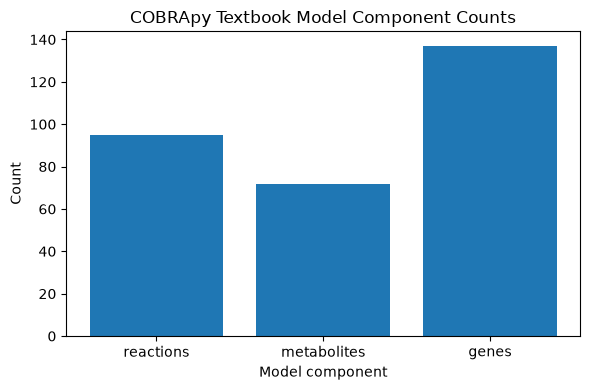

Saved file: outputs\model_component_counts.png


In [14]:
# Create a new figure for the bar plot
plt.figure(figsize=(6, 4))

# Create a bar plot showing the count of each model component
plt.bar(model_counts["component"], model_counts["count"])

# Add a clear plot title
plt.title("COBRApy Textbook Model Component Counts")

# Add x-axis and y-axis labels
plt.xlabel("Model component")
plt.ylabel("Count")

# Keep the x-axis labels horizontal
plt.xticks(rotation=0)

# Improve spacing so labels are not cut off
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig(output_dir / "model_component_counts.png", dpi=300)

# Show the plot inside the notebook
plt.show()

# Confirm that the plot was saved
print("Saved file:", output_dir / "model_component_counts.png")

## Model size summary

The COBRApy `textbook` model contains 95 reactions, 72 metabolites, and 137 genes. This confirms that it is a small core metabolic model, suitable for a first baseline analysis. It is useful for learning the Flux Balance Analysis workflow before applying the same logic to larger genome-scale metabolic models.

This model should be interpreted as a constraint-based tutorial model, not as an experimental fluxomics dataset.

In [15]:
# Get all exchange reactions from the model
exchange_reactions = model.exchanges

# Create a table with basic information about each exchange reaction
exchange_table = pd.DataFrame([
    {
        "reaction_id": reaction.id,
        "reaction_name": reaction.name,
        "reaction_formula": reaction.reaction,
        "lower_bound": reaction.lower_bound,
        "upper_bound": reaction.upper_bound
    }
    for reaction in exchange_reactions
])

# Print the number of exchange reactions
print("Number of exchange reactions:", len(exchange_table))

# Print the exchange reaction table
print("\nExchange reactions table:")
print(exchange_table.to_string(index=False))

# Save the exchange reaction table as a CSV file
exchange_table.to_csv(output_dir / "exchange_reactions.csv", index=False)

# Confirm that the file was saved
print("\nSaved file:", output_dir / "exchange_reactions.csv")

Number of exchange reactions: 20

Exchange reactions table:
reaction_id           reaction_name reaction_formula  lower_bound  upper_bound
    EX_ac_e        Acetate exchange        ac_e -->           0.0       1000.0
 EX_acald_e   Acetaldehyde exchange     acald_e -->           0.0       1000.0
   EX_akg_e 2-Oxoglutarate exchange       akg_e -->           0.0       1000.0
   EX_co2_e            CO2 exchange       co2_e <=>       -1000.0       1000.0
  EX_etoh_e        Ethanol exchange      etoh_e -->           0.0       1000.0
   EX_for_e        Formate exchange       for_e -->           0.0       1000.0
   EX_fru_e     D-Fructose exchange       fru_e -->           0.0       1000.0
   EX_fum_e       Fumarate exchange       fum_e -->           0.0       1000.0
EX_glc__D_e      D-Glucose exchange    glc__D_e <=>         -10.0       1000.0
EX_gln__L_e    L-Glutamine exchange    gln__L_e -->           0.0       1000.0
EX_glu__L_e    L-Glutamate exchange    glu__L_e -->           0.0      

In [16]:
# Get all boundary reactions from the model
boundary_reactions = model.boundary

# Create a table with basic information about each boundary reaction
boundary_table = pd.DataFrame([
    {
        "reaction_id": reaction.id,
        "reaction_name": reaction.name,
        "reaction_formula": reaction.reaction,
        "lower_bound": reaction.lower_bound,
        "upper_bound": reaction.upper_bound
    }
    for reaction in boundary_reactions
])

# Print the number of boundary reactions
print("Number of boundary reactions:", len(boundary_table))

# Print the boundary reaction table
print("\nBoundary reactions table:")
print(boundary_table.to_string(index=False))

# Save the boundary reaction table as a CSV file
boundary_table.to_csv(output_dir / "boundary_reactions.csv", index=False)

# Confirm that the file was saved
print("\nSaved file:", output_dir / "boundary_reactions.csv")

Number of boundary reactions: 20

Boundary reactions table:
reaction_id           reaction_name reaction_formula  lower_bound  upper_bound
    EX_ac_e        Acetate exchange        ac_e -->           0.0       1000.0
 EX_acald_e   Acetaldehyde exchange     acald_e -->           0.0       1000.0
   EX_akg_e 2-Oxoglutarate exchange       akg_e -->           0.0       1000.0
   EX_co2_e            CO2 exchange       co2_e <=>       -1000.0       1000.0
  EX_etoh_e        Ethanol exchange      etoh_e -->           0.0       1000.0
   EX_for_e        Formate exchange       for_e -->           0.0       1000.0
   EX_fru_e     D-Fructose exchange       fru_e -->           0.0       1000.0
   EX_fum_e       Fumarate exchange       fum_e -->           0.0       1000.0
EX_glc__D_e      D-Glucose exchange    glc__D_e <=>         -10.0       1000.0
EX_gln__L_e    L-Glutamine exchange    gln__L_e -->           0.0       1000.0
EX_glu__L_e    L-Glutamate exchange    glu__L_e -->           0.0      

## Exchange and boundary reactions

Exchange reactions represent the interaction between the metabolic model and its external environment. They define which metabolites can enter or leave the system.

In constraint-based models, reaction bounds define the allowed flux range. For exchange reactions, negative lower bounds usually indicate that uptake is allowed, while positive upper bounds allow secretion.

Boundary reactions are a broader category of reactions that define model boundaries. In this small textbook model, the boundary reactions largely correspond to exchange reactions.

In [17]:
# Εισάγουμε το time για να μετρήσουμε πόσο χρόνο χρειάζεται το FBA
import time

# Καταγράφουμε την ώρα πριν ξεκινήσει η βελτιστοποίηση
start_time = time.time()

# Τρέχουμε Flux Balance Analysis με το objective που έχει ήδη οριστεί στο μοντέλο
solution = model.optimize()

# Καταγράφουμε την ώρα αφού τελειώσει η βελτιστοποίηση
end_time = time.time()

# Υπολογίζουμε τον συνολικό χρόνο εκτέλεσης
runtime_seconds = end_time - start_time

# Τυπώνουμε την κατάσταση της λύσης
print("FBA status:", solution.status)

# Τυπώνουμε την τιμή του objective function
print("Objective value:", solution.objective_value)

# Τυπώνουμε τον χρόνο εκτέλεσης
print("Runtime seconds:", runtime_seconds)

FBA status: optimal
Objective value: 0.8739215069684279
Runtime seconds: 0.002704620361328125


In [18]:
# Δημιουργούμε έναν πίνακα με τα βασικά αποτελέσματα του FBA
fba_summary = pd.DataFrame([
    {
        "model_id": model.id,
        "fba_status": solution.status,
        "objective_reaction": ", ".join(objective_reactions),
        "objective_direction": model.objective.direction,
        "objective_value": solution.objective_value,
        "runtime_seconds": runtime_seconds
    }
])

# Τυπώνουμε τον πίνακα ως απλό κείμενο
print("FBA summary table:")
print(fba_summary.to_string(index=False))

# Αποθηκεύουμε τον πίνακα σε CSV αρχείο
fba_summary.to_csv(output_dir / "fba_summary.csv", index=False)

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("\nSaved file:", output_dir / "fba_summary.csv")

FBA summary table:
   model_id fba_status objective_reaction objective_direction  objective_value  runtime_seconds
e_coli_core    optimal Biomass_Ecoli_core                 max         0.873922         0.002705

Saved file: outputs\fba_summary.csv


In [19]:
# Δημιουργούμε πίνακα με όλα τα fluxes από τη λύση του FBA
flux_table = pd.DataFrame({
    "reaction_id": solution.fluxes.index,
    "flux": solution.fluxes.values
})

# Προσθέτουμε πληροφορίες για κάθε reaction από το μοντέλο
flux_table["reaction_name"] = flux_table["reaction_id"].apply(
    lambda reaction_id: model.reactions.get_by_id(reaction_id).name
)

flux_table["reaction_formula"] = flux_table["reaction_id"].apply(
    lambda reaction_id: model.reactions.get_by_id(reaction_id).reaction
)

flux_table["lower_bound"] = flux_table["reaction_id"].apply(
    lambda reaction_id: model.reactions.get_by_id(reaction_id).lower_bound
)

flux_table["upper_bound"] = flux_table["reaction_id"].apply(
    lambda reaction_id: model.reactions.get_by_id(reaction_id).upper_bound
)

# Υπολογίζουμε την απόλυτη τιμή του flux για να μπορούμε να ταξινομήσουμε τις πιο ενεργές reactions
flux_table["absolute_flux"] = flux_table["flux"].abs()

# Ταξινομούμε τις reactions από τη μεγαλύτερη προς τη μικρότερη απόλυτη ροή
flux_table_sorted = flux_table.sort_values("absolute_flux", ascending=False)

# Τυπώνουμε τις 15 reactions με το μεγαλύτερο absolute flux
print("Top 15 reactions by absolute flux:")
print(flux_table_sorted.head(15).to_string(index=False))

# Αποθηκεύουμε όλα τα fluxes σε CSV
flux_table_sorted.to_csv(output_dir / "fba_flux_distribution.csv", index=False)

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("\nSaved file:", output_dir / "fba_flux_distribution.csv")

Top 15 reactions by absolute flux:
reaction_id       flux                                  reaction_name                                       reaction_formula  lower_bound  upper_bound  absolute_flux
     ATPS4r  45.514010        ATP synthase (four protons for one ATP)     adp_c + 4.0 h_e + pi_c <=> atp_c + h2o_c + 3.0 h_c      -1000.0       1000.0      45.514010
      CYTBD  43.598985 cytochrome oxidase bd (ubiquinol-8: 2 protons) 2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_e + q8_c          0.0       1000.0      43.598985
     NADH16  38.534610  NADH dehydrogenase (ubiquinone-8 & 3 protons)   4.0 h_c + nadh_c + q8_c --> 3.0 h_e + nad_c + q8h2_c          0.0       1000.0      38.534610
   EX_h2o_e  29.175827                                   H2O exchange                                             h2o_e <=>       -1000.0       1000.0      29.175827
       H2Ot -29.175827                R H2O transport via - diffusion                                        h2o_e <=> h2o_c      -1000

In [20]:
# Υπολογίζουμε βασικά στατιστικά για τη flux distribution
flux_summary = pd.DataFrame([
    {
        "num_reactions": len(flux_table),
        "num_nonzero_fluxes": (flux_table["flux"] != 0).sum(),
        "num_zero_fluxes": (flux_table["flux"] == 0).sum(),
        "mean_flux": flux_table["flux"].mean(),
        "median_flux": flux_table["flux"].median(),
        "min_flux": flux_table["flux"].min(),
        "max_flux": flux_table["flux"].max(),
        "mean_absolute_flux": flux_table["absolute_flux"].mean(),
        "median_absolute_flux": flux_table["absolute_flux"].median()
    }
])

# Τυπώνουμε το summary table
print("Flux distribution summary:")
print(flux_summary.to_string(index=False))

# Αποθηκεύουμε το summary σε CSV
flux_summary.to_csv(output_dir / "flux_distribution_summary.csv", index=False)

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("\nSaved file:", output_dir / "flux_distribution_summary.csv")

Flux distribution summary:
 num_reactions  num_nonzero_fluxes  num_zero_fluxes  mean_flux  median_flux   min_flux  max_flux  mean_absolute_flux  median_absolute_flux
            95                  53               42   2.627753          0.0 -29.175827  45.51401            5.457075              0.223462

Saved file: outputs\flux_distribution_summary.csv


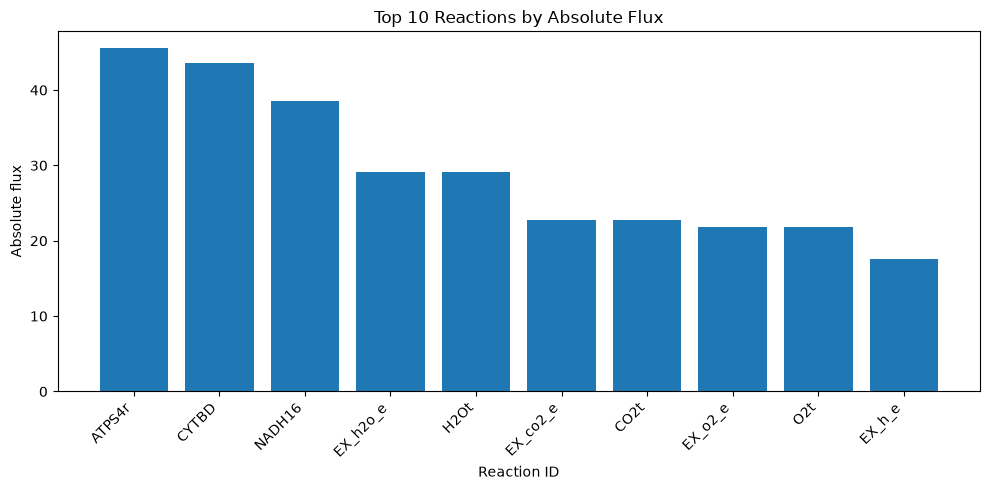

Saved file: outputs\top_10_absolute_fluxes.png


In [21]:
# Κρατάμε τις 10 reactions με το μεγαλύτερο absolute flux
top_fluxes = flux_table_sorted.head(10)

# Δημιουργούμε νέο figure
plt.figure(figsize=(10, 5))

# Φτιάχνουμε bar plot με reaction IDs και absolute flux values
plt.bar(top_fluxes["reaction_id"], top_fluxes["absolute_flux"])

# Προσθέτουμε τίτλο
plt.title("Top 10 Reactions by Absolute Flux")

# Προσθέτουμε labels στους άξονες
plt.xlabel("Reaction ID")
plt.ylabel("Absolute flux")

# Περιστρέφουμε τα reaction IDs για να διαβάζονται καλύτερα
plt.xticks(rotation=45, ha="right")

# Βελτιώνουμε τα περιθώρια του plot
plt.tight_layout()

# Αποθηκεύουμε το plot ως εικόνα
plt.savefig(output_dir / "top_10_absolute_fluxes.png", dpi=300)

# Εμφανίζουμε το plot μέσα στο notebook
plt.show()

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("Saved file:", output_dir / "top_10_absolute_fluxes.png")

## Flux Balance Analysis results

Flux Balance Analysis was performed using the default objective function of the COBRApy `textbook` model. The objective reaction was `Biomass_Ecoli_core`, which represents biomass production and is commonly used as a proxy for cellular growth in constraint-based metabolic models.

The FBA solution status indicates whether the optimization problem was solved successfully. An `optimal` status means that the solver found a feasible optimal solution under the current model constraints.

The objective value is a model-based prediction of maximum biomass production under the selected exchange bounds. It should not be interpreted as an experimentally measured fluxomics value.

The flux distribution table contains the predicted flux through each reaction. Reactions with zero flux are inactive in this specific optimal solution, while reactions with high absolute flux carry more predicted metabolic flow under the current assumptions.

In [22]:
# Εισάγουμε τη συνάρτηση που βρίσκει blocked reactions
from cobra.flux_analysis import find_blocked_reactions

# Καταγράφουμε την ώρα πριν ξεκινήσει ο υπολογισμός
start_time = time.time()

# Βρίσκουμε τις reactions που δεν μπορούν να πάρουν καθόλου flux με τα τρέχοντα constraints
blocked_reaction_ids = find_blocked_reactions(model)

# Καταγράφουμε την ώρα αφού τελειώσει ο υπολογισμός
end_time = time.time()

# Υπολογίζουμε τον χρόνο εκτέλεσης
blocked_runtime_seconds = end_time - start_time

# Υπολογίζουμε πόσες blocked reactions υπάρχουν
num_blocked_reactions = len(blocked_reaction_ids)

# Υπολογίζουμε το ποσοστό blocked reactions στο σύνολο των reactions
blocked_reaction_fraction = num_blocked_reactions / len(model.reactions)

# Τυπώνουμε τα βασικά αποτελέσματα
print("Number of blocked reactions:", num_blocked_reactions)
print("Total number of reactions:", len(model.reactions))
print("Blocked reaction fraction:", blocked_reaction_fraction)
print("Blocked reaction percentage:", blocked_reaction_fraction * 100)
print("Runtime seconds:", blocked_runtime_seconds)

Number of blocked reactions: 8
Total number of reactions: 95
Blocked reaction fraction: 0.08421052631578947
Blocked reaction percentage: 8.421052631578947
Runtime seconds: 11.845219850540161


In [23]:
# Δημιουργούμε πίνακα με πληροφορίες για κάθε blocked reaction
blocked_reactions_table = pd.DataFrame([
    {
        "reaction_id": reaction_id,
        "reaction_name": model.reactions.get_by_id(reaction_id).name,
        "reaction_formula": model.reactions.get_by_id(reaction_id).reaction,
        "lower_bound": model.reactions.get_by_id(reaction_id).lower_bound,
        "upper_bound": model.reactions.get_by_id(reaction_id).upper_bound
    }
    for reaction_id in blocked_reaction_ids
])

# Τυπώνουμε τον πίνακα των blocked reactions
print("Blocked reactions table:")
print(blocked_reactions_table.to_string(index=False))

# Αποθηκεύουμε τον πίνακα σε CSV
blocked_reactions_table.to_csv(output_dir / "blocked_reactions.csv", index=False)

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("\nSaved file:", output_dir / "blocked_reactions.csv")

Blocked reactions table:
reaction_id                                        reaction_name                                           reaction_formula  lower_bound  upper_bound
   EX_fru_e                                  D-Fructose exchange                                                 fru_e -->           0.0       1000.0
   EX_fum_e                                    Fumarate exchange                                                 fum_e -->           0.0       1000.0
EX_gln__L_e                                 L-Glutamine exchange                                              gln__L_e -->           0.0       1000.0
EX_mal__L_e                                    L-Malate exchange                                              mal__L_e -->           0.0       1000.0
    FRUpts2 R Fructose transport via PEPPyr PTS-f6p - generating                            fru_e + pep_c --> f6p_c + pyr_c          0.0       1000.0
    FUMt2_2        R Fumarate transport via proton symport-2 - H           

In [24]:
# Δημιουργούμε συνοπτικό πίνακα για τις blocked reactions
blocked_summary = pd.DataFrame([
    {
        "model_id": model.id,
        "total_reactions": len(model.reactions),
        "num_blocked_reactions": num_blocked_reactions,
        "blocked_reaction_fraction": blocked_reaction_fraction,
        "blocked_reaction_percentage": blocked_reaction_fraction * 100,
        "runtime_seconds": blocked_runtime_seconds
    }
])

# Τυπώνουμε το summary table
print("Blocked reaction summary:")
print(blocked_summary.to_string(index=False))

# Αποθηκεύουμε το summary σε CSV
blocked_summary.to_csv(output_dir / "blocked_reaction_summary.csv", index=False)

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("\nSaved file:", output_dir / "blocked_reaction_summary.csv")

Blocked reaction summary:
   model_id  total_reactions  num_blocked_reactions  blocked_reaction_fraction  blocked_reaction_percentage  runtime_seconds
e_coli_core               95                      8                   0.084211                     8.421053         11.84522

Saved file: outputs\blocked_reaction_summary.csv


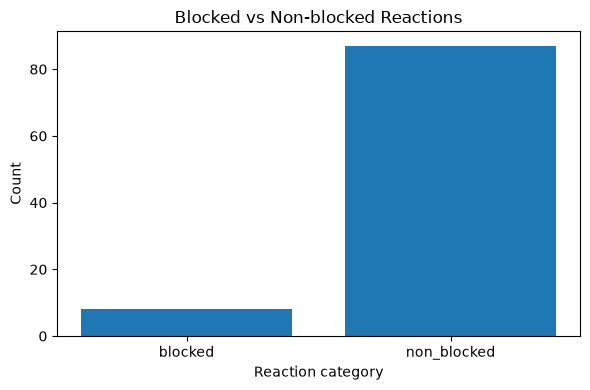

Saved file: outputs\blocked_vs_non_blocked_reactions.png


In [25]:
# Υπολογίζουμε πόσες reactions δεν είναι blocked
num_non_blocked_reactions = len(model.reactions) - num_blocked_reactions

# Δημιουργούμε έναν μικρό πίνακα για το plot
blocked_plot_data = pd.DataFrame({
    "category": ["blocked", "non_blocked"],
    "count": [num_blocked_reactions, num_non_blocked_reactions]
})

# Δημιουργούμε νέο figure
plt.figure(figsize=(6, 4))

# Φτιάχνουμε bar plot για blocked και non-blocked reactions
plt.bar(blocked_plot_data["category"], blocked_plot_data["count"])

# Προσθέτουμε τίτλο
plt.title("Blocked vs Non-blocked Reactions")

# Προσθέτουμε labels στους άξονες
plt.xlabel("Reaction category")
plt.ylabel("Count")

# Βελτιώνουμε τα περιθώρια
plt.tight_layout()

# Αποθηκεύουμε το plot ως εικόνα
plt.savefig(output_dir / "blocked_vs_non_blocked_reactions.png", dpi=300)

# Εμφανίζουμε το plot μέσα στο notebook
plt.show()

# Επιβεβαιώνουμε ότι αποθηκεύτηκε
print("Saved file:", output_dir / "blocked_vs_non_blocked_reactions.png")

## Blocked reaction analysis

Blocked reactions are reactions that cannot carry any flux under the current model constraints. This is different from reactions with zero flux in one optimal FBA solution. A reaction may have zero flux in the optimal solution but still be capable of carrying flux under another feasible flux distribution.

The blocked reaction fraction was calculated as:

blocked reaction fraction = number of blocked reactions / total number of reactions

This metric provides a simple indication of how much of the model is inactive or unreachable under the current exchange bounds and network constraints. In this baseline notebook, the result should be interpreted within the COBRApy textbook model assumptions, not as an experimental fluxomics measurement.

In [26]:
# Εμφανίζουμε όλα τα αρχεία που δημιουργήθηκαν στον φάκελο outputs
print("Files created in the outputs folder:")

for file_path in output_dir.iterdir():
    print(file_path)

Files created in the outputs folder:
outputs\blocked_reactions.csv
outputs\blocked_reaction_summary.csv
outputs\blocked_vs_non_blocked_reactions.png
outputs\boundary_reactions.csv
outputs\exchange_reactions.csv
outputs\fba_flux_distribution.csv
outputs\fba_summary.csv
outputs\final_baseline_summary.csv
outputs\flux_distribution_summary.csv
outputs\model_component_counts.png
outputs\model_counts.csv
outputs\model_metadata.csv
outputs\reproducibility_info.csv
outputs\top_10_absolute_fluxes.png


## Final baseline interpretation

The COBRApy `textbook` model was successfully loaded and analyzed as a small constraint-based model of E. coli core metabolism. The model contains 95 reactions, 72 metabolites, and 137 genes.

Flux Balance Analysis returned an `optimal` solution, meaning that the optimization problem was feasible and successfully solved under the current model constraints. The objective reaction was `Biomass_Ecoli_core`, and the objective value was approximately 0.8739. This value represents a model-based prediction of biomass production under the default exchange bounds.

The flux distribution showed that 53 reactions carried non-zero flux in the selected optimal FBA solution, while 42 reactions had zero flux. However, zero flux in one optimal solution does not necessarily mean that a reaction is blocked.

Blocked reaction analysis identified 8 blocked reactions out of 95 total reactions, corresponding to a blocked reaction fraction of approximately 0.0842, or 8.42%. These blocked reactions cannot carry flux under the current model constraints.

Overall, this notebook should be interpreted as a baseline model-first analysis using a tutorial constraint-based metabolic model, not as an experimental fluxomics dataset.

In [27]:
# Create one final summary table with the key baseline results
final_baseline_summary = pd.DataFrame([
    {
        "model_id": model.id,
        "num_reactions": len(model.reactions),
        "num_metabolites": len(model.metabolites),
        "num_genes": len(model.genes),
        "num_exchange_reactions": len(exchange_table),
        "num_boundary_reactions": len(boundary_table),
        "fba_status": solution.status,
        "objective_reaction": ", ".join(objective_reactions),
        "objective_value": solution.objective_value,
        "fba_runtime_seconds": runtime_seconds,
        "num_nonzero_fluxes": int((flux_table["flux"] != 0).sum()),
        "num_zero_fluxes": int((flux_table["flux"] == 0).sum()),
        "num_blocked_reactions": num_blocked_reactions,
        "blocked_reaction_fraction": blocked_reaction_fraction,
        "blocked_reaction_percentage": blocked_reaction_fraction * 100,
        "blocked_analysis_runtime_seconds": blocked_runtime_seconds
    }
])

# Print the final summary table
print("Final baseline summary:")
print(final_baseline_summary.to_string(index=False))

# Save the final summary table as a CSV file
final_baseline_summary.to_csv(output_dir / "final_baseline_summary.csv", index=False)

# Confirm that the file was saved
print("\nSaved file:", output_dir / "final_baseline_summary.csv")

Final baseline summary:
   model_id  num_reactions  num_metabolites  num_genes  num_exchange_reactions  num_boundary_reactions fba_status objective_reaction  objective_value  fba_runtime_seconds  num_nonzero_fluxes  num_zero_fluxes  num_blocked_reactions  blocked_reaction_fraction  blocked_reaction_percentage  blocked_analysis_runtime_seconds
e_coli_core             95               72        137                      20                      20    optimal Biomass_Ecoli_core         0.873922             0.002705                  53               42                      8                   0.084211                     8.421053                          11.84522

Saved file: outputs\final_baseline_summary.csv


In [28]:
# Import platform to record basic system information
import platform

# Create a reproducibility table with package and system information
reproducibility_info = pd.DataFrame([
    {
        "python_version": platform.python_version(),
        "cobra_version": cobra.__version__,
        "pandas_version": pd.__version__,
        "numpy_version": np.__version__,
        "model_id": model.id
    }
])

# Print reproducibility information
print("Reproducibility information:")
print(reproducibility_info.to_string(index=False))

# Save reproducibility information as CSV
reproducibility_info.to_csv(output_dir / "reproducibility_info.csv", index=False)

# Confirm that the file was saved
print("\nSaved file:", output_dir / "reproducibility_info.csv")

Reproducibility information:
python_version cobra_version pandas_version numpy_version    model_id
        3.14.6        0.31.1          2.3.3         2.4.6 e_coli_core

Saved file: outputs\reproducibility_info.csv


In [29]:
# Display all files created in the outputs folder
print("Files created in the outputs folder:")

for file_path in sorted(output_dir.iterdir()):
    print(file_path)

Files created in the outputs folder:
outputs\blocked_reaction_summary.csv
outputs\blocked_reactions.csv
outputs\blocked_vs_non_blocked_reactions.png
outputs\boundary_reactions.csv
outputs\exchange_reactions.csv
outputs\fba_flux_distribution.csv
outputs\fba_summary.csv
outputs\final_baseline_summary.csv
outputs\flux_distribution_summary.csv
outputs\model_component_counts.png
outputs\model_counts.csv
outputs\model_metadata.csv
outputs\reproducibility_info.csv
outputs\top_10_absolute_fluxes.png
